Лабораторная работа 2

Васин Григорий М8О-309Б-22

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import warnings
warnings.simplefilter("ignore")
sns.set(style="darkgrid")

In [3]:
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

In [4]:
train_data.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,...,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2010-06-26,27.0,66829.0,549.0,17290.0,60.0,Divorced,1.0,Rent,1095.0,...,Employed,Associate,4.0,35067.0,0.257790,0.251465,508.970230,0.288013,0.0,66.176500
1,1996-09-23,55.0,172147.0,850.0,16110.0,36.0,Widowed,1.0,Mortgage,211.0,...,Employed,High School,33.0,27001.0,0.086110,0.093173,514.675859,0.050585,1.0,28.495737
2,2015-01-19,51.0,300000.0,850.0,38436.0,36.0,Married,0.0,Mortgage,546.0,...,Employed,Bachelor,28.0,278382.0,0.108436,0.115443,1268.276385,0.072571,1.0,34.488104
3,1981-05-12,25.0,34683.0,847.0,19186.0,48.0,Married,0.0,Other,153.0,...,Employed,High School,0.0,9224.0,0.100686,0.112822,498.505187,0.225415,1.0,36.910753
4,1995-05-07,55.0,300000.0,850.0,30437.0,48.0,Single,2.0,Rent,562.0,...,Employed,Bachelor,31.0,4502.0,0.110437,0.089037,756.035156,0.052721,1.0,31.347091


In [5]:
test_data.head()

,ID,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,...,JobTenure,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved
0,0,1979-01-03,49,207095,850,14458,60,Single,0,Rent,...,6,Employed,High School,23,10626,0.104458,0.125350,325.532336,0.040650,1
1,1,2006-04-10,28,64653,674,65491,48,Single,2,Own,...,3,Employed,High School,3,299024,0.233491,0.260561,2210.247757,0.454410,0
2,2,2013-11-28,41,300000,768,16811,60,Single,1,Own,...,3,Employed,High School,19,6979,0.147811,0.154571,403.977431,0.034919,1
3,3,1995-08-24,50,300000,850,48737,36,Divorced,0,Mortgage,...,3,Self-Employed,Bachelor,26,8438,0.118737,0.099712,1571.946906,0.085558,1
4,4,1980-06-15,35,300000,672,51916,60,Single,6,Mortgage,...,7,Employed,Associate,12,436216,0.230916,0.237727,1486.675235,0.063707,1


In [6]:
train_data.isnull().sum()

ApplicationDate                530
Age                            530
AnnualIncome                   530
CreditScore                   1031
LoanAmount                    1031
LoanDuration                   530
MaritalStatus                  530
NumberOfDependents             530
HomeOwnershipStatus            530
MonthlyDebtPayments           1031
CreditCardUtilizationRate      530
NumberOfOpenCreditLines        530
NumberOfCreditInquiries        530
DebtToIncomeRatio              530
BankruptcyHistory             1031
LoanPurpose                   1031
PreviousLoanDefaults           530
PaymentHistory                 530
LengthOfCreditHistory          530
SavingsAccountBalance          530
CheckingAccountBalance        1031
TotalAssets                   1031
TotalLiabilities               530
MonthlyIncome                  530
UtilityBillsPaymentHistory     530
JobTenure                      530
EmploymentStatus               530
EducationLevel                 530
Experience          

посмотрим распределения

<Axes: xlabel='LoanApproved', ylabel='count'>

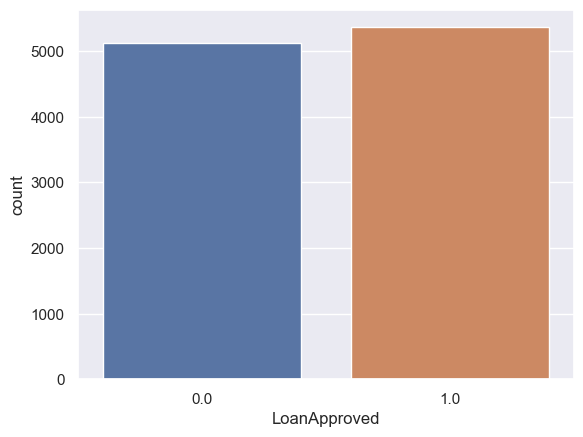

In [12]:
tr_data_value_counts = train_data['LoanApproved'].value_counts()
sns.countplot(x='LoanApproved', data=train_data)

поработаем с признаками

In [17]:
num_columns = train_data.select_dtypes(include=['float64']).columns   #стольцы с числовыми признаками
cat_columns = train_data.select_dtypes(include=['object']).columns   #столбцы с категориальными признаками

#заполним пропуски числовые медианой
median = train_data[num_columns].median()
train_data[num_columns] = train_data[num_columns].fillna(median)

#заменим пропущенные значения у категориальных признаков 
for col in cat_columns:
    train_data[col] = train_data[col].fillna(train_data[col].mode()[0])    

In [19]:
#преобразуем категориальные признаки
label_encoder = LabelEncoder()
for col in cat_columns:
    train_data[col] = label_encoder.fit_transform(train_data[col])

In [20]:
X = train_data.drop('LoanApproved', axis=1)
y = train_data['LoanApproved']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
#делаем стандартизацию
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
class CustomLogisticRegression:
    def __init__(self, learning_rate=0.01, num_iterations=1000):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.zeros(n)
        self.bias = 0

        for _ in range(self.num_iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            predictions = self.sigmoid(linear_model)
            dw = (1/m) * np.dot(X.T, (predictions - y))
            db = (1/m) * np.sum(predictions - y)
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        predictions = self.sigmoid(linear_model)
        return [1 if p > 0.5 else 0 for p in predictions]

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

In [31]:
def train_and_evaluate(model, X_train, X_test, y_train, y_test):
    # Обучение модели
    model.fit(X_train, y_train)
    
    # Предсказания на тестовом наборе
    y_pred = model.predict(X_test)
    
    # Расчет метрик
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    return accuracy, precision, recall, f1, cm



In [23]:
custom_lr = CustomLogisticRegression()

In [24]:
custom_lr.fit(X_train_scaled, y_train)

In [25]:
y_pred_custom = custom_lr.predict(X_test_scaled)

In [26]:
cm_custom = confusion_matrix(y_test, y_pred_custom)

In [27]:
metrics_custom = {
    'Accuracy': accuracy_score(y_test, y_pred_custom),
    'Precision': precision_score(y_test, y_pred_custom),
    'Recall': recall_score(y_test, y_pred_custom),
    'F1-score': f1_score(y_test, y_pred_custom)
}

In [42]:
#Sklearn Logistic Regression
model_lr = LogisticRegression(max_iter=1000)
accuracy_lr, precision_lr, recall_lr, f1_lr, cm_lr = train_and_evaluate(model_lr, X_train, X_test, y_train, y_test)

In [43]:
#SVM
model_svm = SVC(probability=True)
accuracy_svm, precision_svm, recall_svm, f1_svm, cm_svm = train_and_evaluate(model_svm, X_train, X_test, y_train, y_test)

In [44]:
#Decision Tree
model_dt = DecisionTreeClassifier()
accuracy_dt, precision_dt, recall_dt, f1_dt, cm_dt = train_and_evaluate(model_dt, X_train, X_test, y_train, y_test)

In [45]:
#Random Forest
model_rf = RandomForestClassifier()
accuracy_rf, precision_rf, recall_rf, f1_rf, cm_rf = train_and_evaluate(model_rf, X_train, X_test, y_train, y_test)

In [46]:
#Gradient Boosting
model_gb = GradientBoostingClassifier()
accuracy_gb, precision_gb, recall_gb, f1_gb, cm_gb = train_and_evaluate(model_gb, X_train, X_test, y_train, y_test)

In [47]:
#LightGBM
model_lgb = lgb.LGBMClassifier()
accuracy_lgb, precision_lgb, recall_lgb, f1_lgb, cm_lgb = train_and_evaluate(model_lgb, X_train, X_test, y_train, y_test)

[LightGBM] [Info] Number of positive: 4710, number of negative: 4103
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000590 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5090
[LightGBM] [Info] Number of data points in the train set: 8813, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.534438 -> initscore=0.137969
[LightGBM] [Info] Start training from score 0.137969


In [48]:
#XGBoost
model_xgb = xgb.XGBClassifier()
accuracy_xgb, precision_xgb, recall_xgb, f1_xgb, cm_xgb = train_and_evaluate(model_xgb, X_train, X_test, y_train, y_test)

In [49]:
#CatBoost
model_cb = CatBoostClassifier(verbose=0)
accuracy_cb, precision_cb, recall_cb, f1_cb, cm_cb = train_and_evaluate(model_cb, X_train, X_test, y_train, y_test)

In [50]:
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()

графики

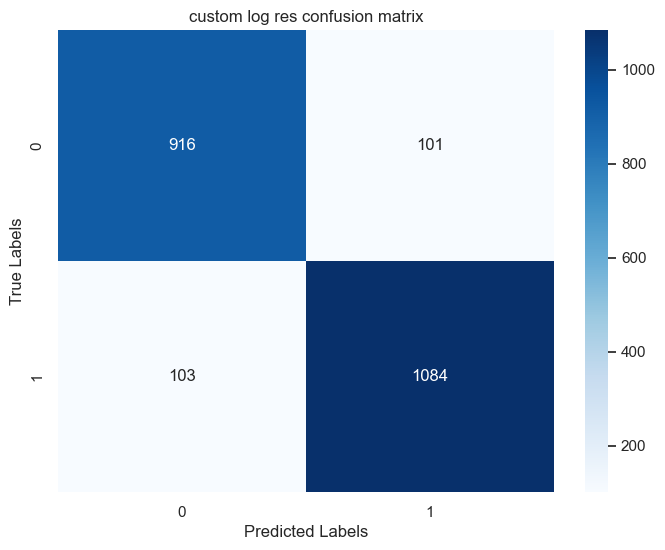

In [53]:
plot_confusion_matrix(cm_custom, 'custom log res confusion matrix')

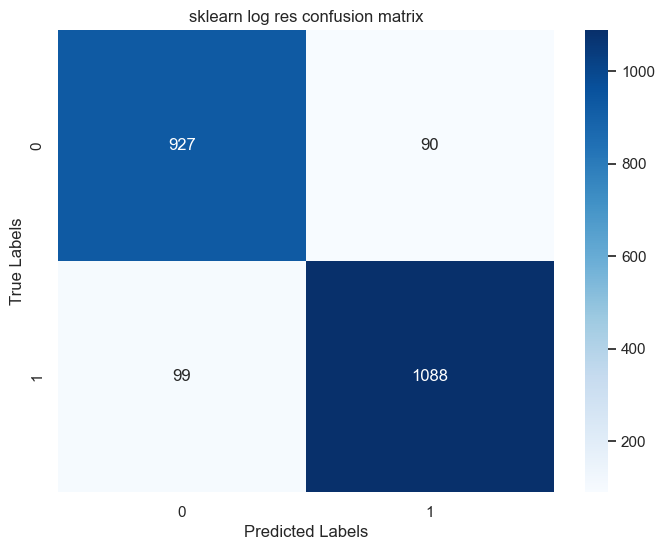

In [54]:
plot_confusion_matrix(cm_lr, 'sklearn log res confusion matrix')

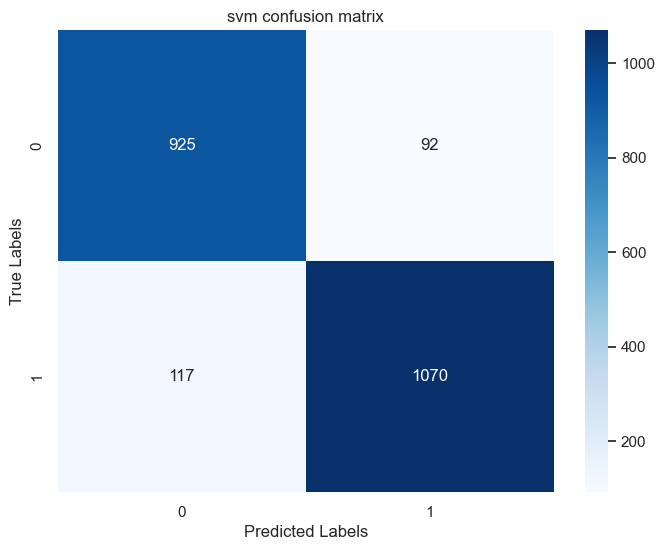

In [55]:
plot_confusion_matrix(cm_svm, 'svm confusion matrix')

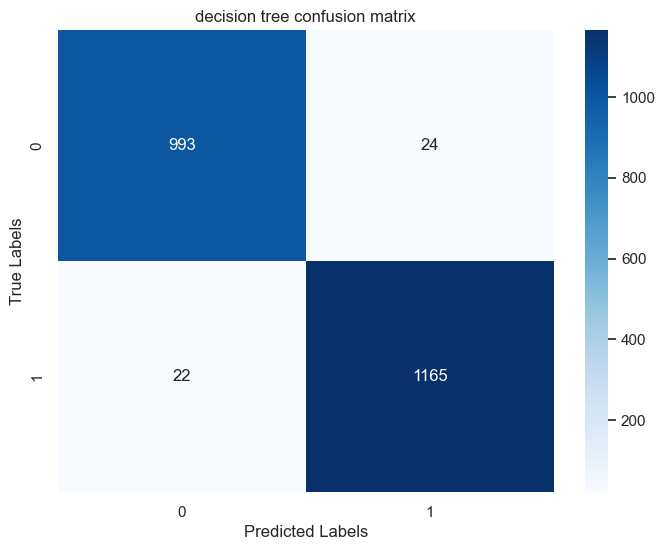

In [56]:
plot_confusion_matrix(cm_dt, 'decision tree confusion matrix')

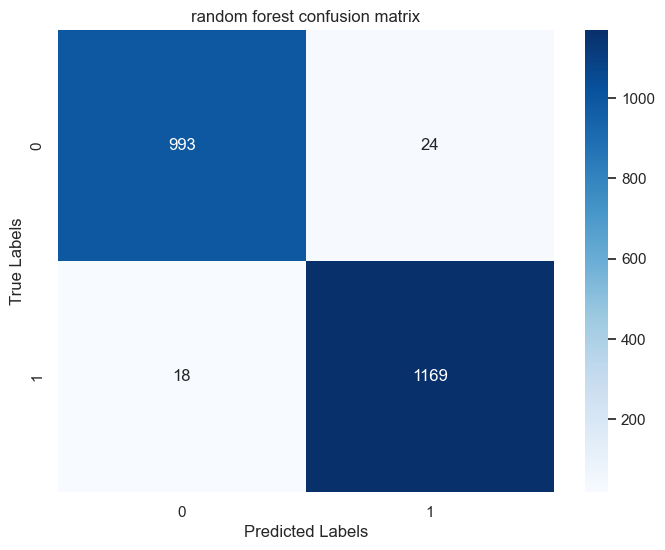

In [58]:
plot_confusion_matrix(cm_rf, 'random forest confusion matrix')

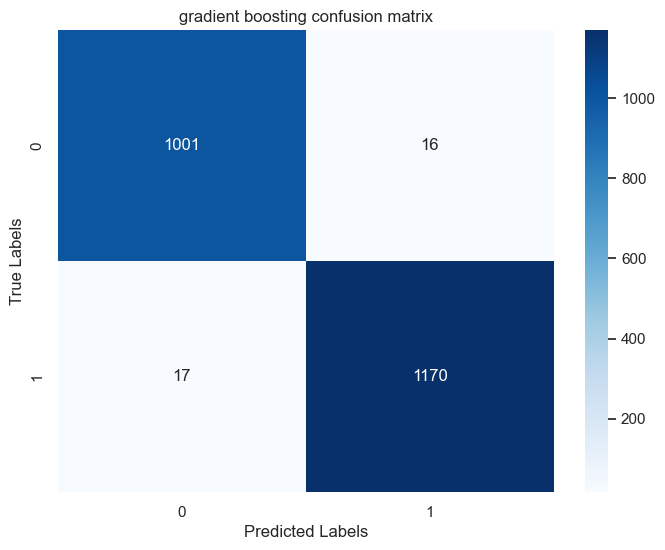

In [59]:
plot_confusion_matrix(cm_gb, 'gradient boosting confusion matrix')

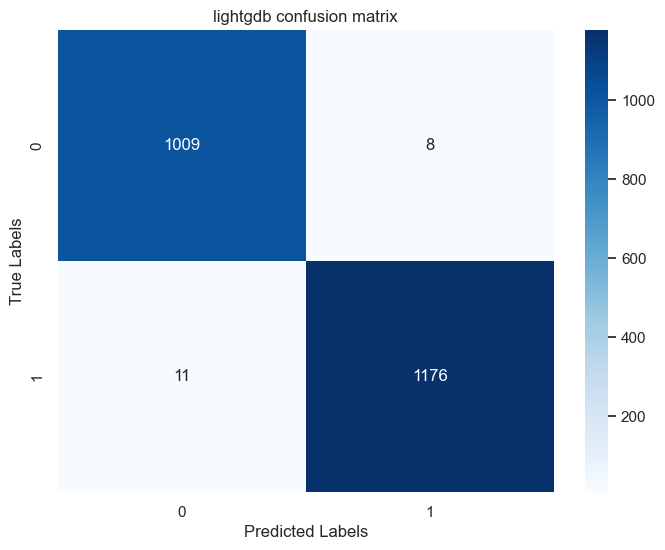

In [60]:
plot_confusion_matrix(cm_lgb, 'lightgdb confusion matrix')

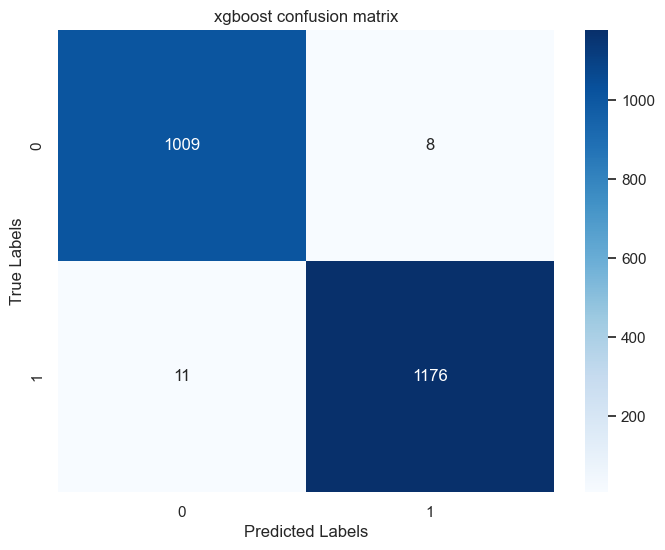

In [61]:
plot_confusion_matrix(cm_xgb, 'xgboost confusion matrix')

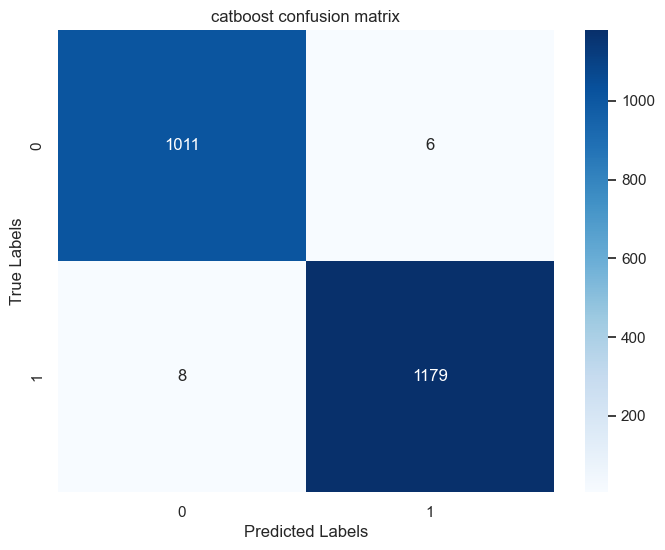

In [62]:
plot_confusion_matrix(cm_cb, 'catboost confusion matrix')

метрики

In [63]:

metrics_df = pd.DataFrame({
    'Model': ['Custom Logistic Regression', 'Sklearn Logistic Regression', 'SVM', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'LightGBM', 'XGBoost', 'CatBoost'],
    'Accuracy': [metrics_custom['Accuracy'], accuracy_lr, accuracy_svm, accuracy_dt, accuracy_rf, accuracy_gb, accuracy_lgb, accuracy_xgb, accuracy_cb],
    'Precision': [metrics_custom['Precision'], precision_lr, precision_svm, precision_dt, precision_rf, precision_gb, precision_lgb, precision_xgb, precision_cb],
    'Recall': [metrics_custom['Recall'], recall_lr, recall_svm, recall_dt, recall_rf, recall_gb, recall_lgb, recall_xgb, recall_cb],
    'F1-score': [metrics_custom['F1-score'], f1_lr, f1_svm, f1_dt, f1_rf, f1_gb, f1_lgb, f1_xgb, f1_cb]
})

print(metrics_df)

                         Model  Accuracy  Precision    Recall  F1-score
0   Custom Logistic Regression  0.907441   0.914768  0.913227  0.913997
1  Sklearn Logistic Regression  0.914247   0.923599  0.916596  0.920085
2                          SVM  0.905172   0.920826  0.901432  0.911026
3                Decision Tree  0.979129   0.979815  0.981466  0.980640
4                Random Forest  0.980944   0.979883  0.984836  0.982353
5            Gradient Boosting  0.985027   0.986509  0.985678  0.986094
6                     LightGBM  0.991379   0.993243  0.990733  0.991987
7                      XGBoost  0.991379   0.993243  0.990733  0.991987
8                     CatBoost  0.993648   0.994937  0.993260  0.994098


Custom Logistic Regression показала хорошие результаты с учетом базового подхода, однако уступает более сложным алгоритмам. Тем не менее, это решение может быть полезным для начального анализа данных или при необходимости минимизировать вычислительные затраты.

Логистическая регрессия (sklearn) демонстрирует уверенные показатели, особенно по метрикам точности и полноты. Однако, учитывая сложность задачи, она может быть недостаточно гибкой для учета нелинейных зависимостей.

SVM показывает сопоставимые с логистической регрессией результаты. Эта модель лучше справляется с разделением классов в сложных случаях, но несколько уступает по метрике полноты, что может быть важно в контексте задачи.

Дерево решений демонстрирует впечатляющие результаты с высокой точностью, полнотой и F1-мерой. Однако, из-за склонности к переобучению, эту модель следует использовать с осторожностью, особенно на больших наборах данных.

Случайный лес превосходит дерево решений, достигая высокой точности и полноты. Это говорит о том, что ансамблевый подход помогает устранить недостатки отдельных деревьев и лучше улавливать важные зависимости.

Gradient Boosting показывает сбалансированные и высокие метрики. Эта модель хорошо подходит для обработки сложных данных, минимизируя ошибки за счет использования слабых моделей.

LightGBM и XGBoost достигают практически идентичных результатов, демонстрируя отличную эффективность. Эти модели особенно хорошо подходят для работы с большим объемом данных и большим количеством признаков, эффективно обрабатывая сложные зависимости.

CatBoost является лидером среди всех протестированных моделей. Она показала наивысшие значения точности, полноты и F1-меры, что подтверждает ее высокую адаптивность и эффективность при работе с категориальными признаками.